## Task 2

len R = 208787
len t = 208787
Ns = 100


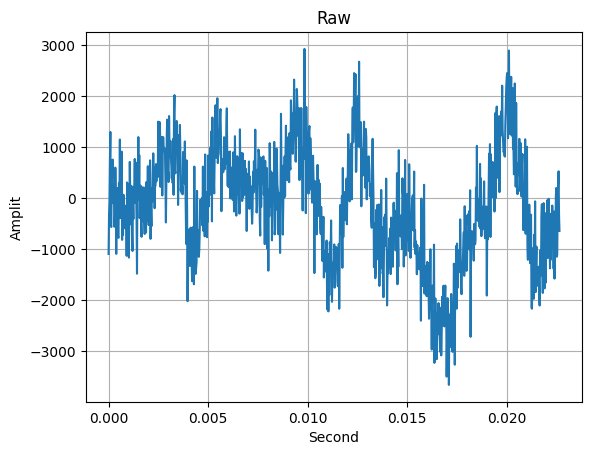

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.io as sio

fs = 44100
fc = 4000
Ts = 0.0022676
Ns = int(round(fs * Ts))

data = sio.loadmat("Signals_task2/Signal3.mat")
R = np.ravel(data["R"])
t = np.ravel(data["t"])

print("len R =", len(R))
print("len t =", len(t))
print("Ns =", Ns)

plt.plot(t[:1000], R[:1000])
plt.title("Raw")
plt.xlabel("Second")
plt.ylabel("Amplit")
plt.grid()
plt.show()


## Down conversion

Best timing offset: 38
nbr of samples: 2089


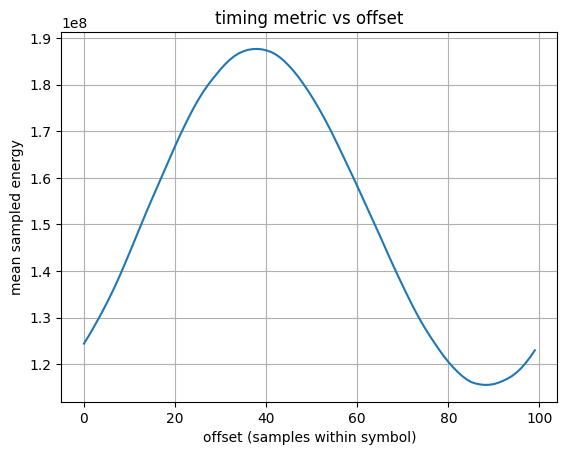

In [15]:
# downconvert to complex
n = np.arange(len(R))
r_bb = 2 * R * np.exp(-1j * 2 * np.pi * fc * n / fs)

# half-cycle sinus pulse
t_pulse = np.arange(Ns) / fs
p = np.sin(np.pi * t_pulse / Ts)

# matched filter
y = np.convolve(r_bb, p[::-1], mode="full")

# Try possible offsets inside one symbol
timing_metric = np.array([np.mean(np.abs(y[o::Ns])**2) for o in range(Ns)])
best_offset = int(np.argmax(timing_metric))

z_all = y[best_offset::Ns]

print("Best timing offset:", best_offset)
print("nbr of samples:", len(z_all))

plt.plot(timing_metric)
plt.title("timing metric vs offset")
plt.xlabel("offset (samples within symbol)")
plt.ylabel("mean sampled energy")
plt.grid()
plt.show()